Scenario 1; Stable oscillations over 70 months

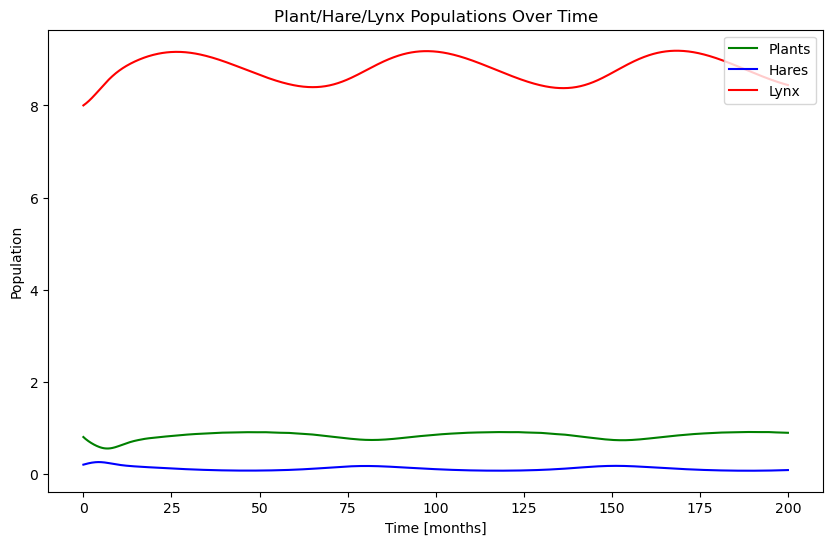

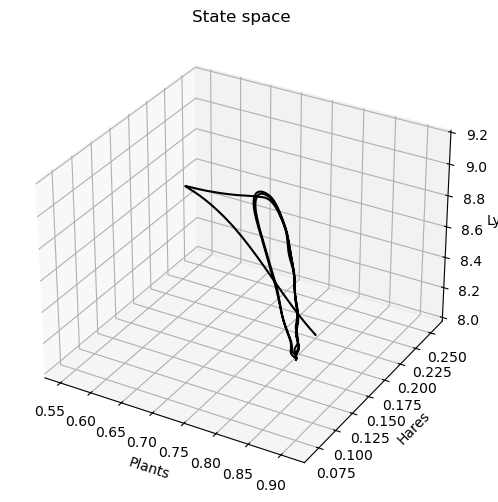

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define the 3-species system of ODEs
def plants_hare_lynx(t, y, a1, a2, b1, b2, d1, d2):
    dy0 = y[0]*(1-y[0]) - ((a1*y[0])/(1+b1*y[0]))*y[1]
    dy1 = ((a1*y[0])/(1+b1*y[0]))*y[1] - d1*y[1] - (a2*y[1]/(1+b2*y[1]))*y[2]
    dy2 = (a2*y[1]/(1+b2*y[1]))*y[2] - d2*y[2]
    return [dy0, dy1, dy2]

t0 = 0                    # start time of simulation [in months]
tfinal = 200              # end time of simulation [in months] 
y0 = [0.8, 0.2, 8]      # initial state: [plants, hares, lynx] at t=0
tspan = (t0, tfinal)      # time span

# 3-Species Parameters (You will change these for Task 2)
a1, a2 = 5.0, 0.1
b1, b2 = 3.0, 1.0
d1, d2 = 0.4, 0.01

# The system of ODEs is solved numerically
t_eval = np.linspace(t0, tfinal, 1000)
sol = solve_ivp(lambda t, y: plants_hare_lynx(t, y, a1, a2, b1, b2, d1, d2), 
                tspan, y0, t_eval=t_eval, method='RK23')

# Plot population over time
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sol.t, sol.y[0], label='Plants', color='green')
ax.plot(sol.t, sol.y[1], label='Hares', color='blue')
ax.plot(sol.t, sol.y[2], label='Lynx', color='red')
ax.set_title('Plant/Hare/Lynx Populations Over Time')
ax.set_xlabel('Time [months]')
ax.set_ylabel('Population')
ax.legend(loc='upper right')
plt.show()

# Plot state space (Updated to 3D for three species)

fig2 = plt.figure(figsize=(8, 6))
ax2 = fig2.add_subplot(111, projection='3d')
ax2.plot(sol.y[0], sol.y[1], sol.y[2], color='black')
ax2.set_title('State space')
ax2.set_xlabel('Plants')
ax2.set_ylabel('Hares')
ax2.set_zlabel('Lynx')
plt.show()